# BB84 QKD Parameters Optimization

## Fiber Lengths and n_X Values
Fiber lengths are created from 0 to 200 km in 0.1 km steps, resulting in 2001 unique fiber lengths. \
$n_X$ values are used ranging from $10^6$ to $10^{10}$, creating 5 unique values. \
Form all combinations of fiber lengths and $n_X$, resulting in 2001 $\times$ 5 = 10,005 combinations, which aligns with the aim to generate a large dataset.

## Optimization Process:
For each combination of fiber length $L$ and $n_X$, The parameters $\vec{p}$ = $ [ \mu_1, \mu_2, P_{\mu_1}, P_{\mu_2}, P_X ]$ are optimized using dual_annealing, which is a global optimization algorithm. \
The objective function is wrapped to evaluate the key rate for a specific combination of fiber length and $n_X$. 

## Parallelization:
joblib’s Parallel is used to run the optimization for all combinations in parallel, with 12 threads, making the process efficient. \
tqdm-joblib is also used to track progress visually. 

## Dataset Creation:
The results of the optimization ($e_1, e_2, e_3, e_4, n_X, R, p_{opt}$) are collected into a dataset. \
This dataset is saved to a file (training_dataset.json) for training a neural network. 




## Setup

### Framework Selection:JAX
Functional Programming: Simplify scientific computation and optimization workflows. \
Smaller Footprint: Ideal if the project doesn’t leverage TensorFlow’s broader ecosystem.

##### Key Considerations
For numerically intensive workloads (e.g., optimization tasks like QKD key rate calculations), JAX excels due to its lightweight functional paradigm.

##### Conclusion
Use JAX for performance-critical, purely numerical optimization tasks with minimal dependencies on machine learning frameworks.

## Imports

In [1]:
# Import necessary libraries
import os
import sys

# Get the notebook's directory
notebook_dir = os.getcwd()
# Add parent directory to path
project_root = os.path.dirname(notebook_dir)
sys.path.append(project_root)

import time
import json
import functools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
from joblib import Parallel, delayed
from concurrent.futures import ProcessPoolExecutor
from collections import defaultdict
from scipy.optimize import minimize, dual_annealing, differential_evolution, Bounds
from src.qkd.model import calculate_key_rates_and_metrics, objective, penalty, objective_val_and_grad
# JAX imports
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap
from jax.scipy.special import logsumexp, gamma
from jax.experimental import pjit
from jax.sharding import Mesh
# FORCE CPU for 64-bit precision (Metal/GPU lacks f64 support currently)
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu") # CRITICAL FIX
# SciPy imports
from math import exp, factorial

# JAX configuration for double precision
jax.config.update("jax_enable_x64", True)





/Users/daai6ga1hou2/anaconda3/envs/qkd-opt/lib/python3.10/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
print(jax.devices())

Metal device set to: Apple M2 Pro

systemMemory: 32.00 GB
maxCacheSize: 10.67 GB

[CpuDevice(id=0)]


W0000 00:00:1768876766.855134 1416191 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1768876766.871894 1416191 service.cc:145] XLA service 0x102f96d90 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768876766.871906 1416191 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1768876766.873284 1416191 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1768876766.873297 1416191 mps_client.cc:384] XLA backend will use up to 22906109952 bytes on device 0 for SimpleAllocator.


In [3]:
# pip install jax --upgrade s

## Experimental Parameters

In [4]:
# e_1
# Fiber lengths
Ls = jnp.linspace(0, 200, 1000)  # Fiber lengths in km
L_BC = Ls
e_1 = L_BC / 100
    
#e_2
P_dc_value = 6*10**-7  # Dark count probability
Y_0 = P_dc_value
# 2.7*10** -7
# P_dc = 6 * 10 ** (-7)   # given in the paper, discussed with range from 10^-8 to 10^-5
e_2 = -jnp.log(Y_0)

# e_3
e_mis = 5 * 10 ** -3  # Misalignment error probability
# 0.026 
e_d = e_mis
e_3 = e_d * 100
e_mis = 5*1e-3 # given in the paper, discussed with range from 0 to 0.1 

# e_4
# Detected events
n_X_values = [10**9] #[10 ** s for s in range(4, 11)]  # Detected events
# n_X_values = jnp.array([10**s for s in range(6, 11)], dtype=jnp.int64)
N = jnp.array(n_X_values)
e_4 = jnp.log(N)

## Other Parameters

In [5]:
alpha = 0.2  # Attenuation coefficient (dB/km), given in the paper
eta_Bob = 0.1  # Detector efficiency, given in the paper
P_ap = 0  # After-pulse probability
f_EC = 1.16  # Error correction efficiency
# secutity error 
epsilon_sec = 1e-10 # is equal to kappa * secrecy length Kl, range around 1e-10 Scalar, as it is a single value throughout the calculations.
# correlation error
epsilon_cor = 1e-15 # given in the paper, discussed with range from 0 to 10e-10
# Dark count probability
n_event = 1  # for single photon event
# Misalignment error probability
# 4*1e-2          # given in the paper, discussed with range from 0 to 0.1
kappa = 1e-15           # given in the paper
f_EC = 1.16             # given in the paper, range around 1.1


## Optimal Paramters

In [6]:
def optimal_parameters(params):
    mu_1, mu_2, P_mu_1, P_mu_2, P_X_value = params
    mu_3 = 2e-4
    P_mu_3 = 1 - P_mu_1 - P_mu_2
    P_Z_value = 1 - P_X_value
    mu_k_values = jnp.array([mu_1, mu_2, mu_3])
    return params, mu_3, P_mu_3, P_Z_value, mu_k_values

## Functions

The calculate_factorial function provided uses the gamma function to compute the factorial of a number  n . This is mathematically correct because the gamma function  \Gamma(n+1)  is equivalent to the factorial  n!  for non-negative integers  n .

## Mathematical Background
The gamma function is defined as:
$\Gamma(x) = \int_0^\infty t^{x-1} e^{-t} \, dt$ \
For positive integers, the gamma function satisfies the relationship: \
$\Gamma(n + 1) = n!$
\
JAX does not have a built-in factorial function, but it does support the gamma function. This makes the approach valid and compatible with JAX for automatic differentiation and JIT compilation.

In [7]:
# Import the physics engine from the src folder
from src.qkd.physics import (
    calculate_eta_ch, calculate_eta_sys, calculate_D_mu_k, 
    calculate_n_X_total, calculate_N, calculate_n_Z_total,
    calculate_e_mu_k, calculate_e_obs, calculate_h, calculate_lambda_EC,
    calculate_sqrt_term, calculate_n_pm, calculate_S_0, calculate_S_1,
    calculate_m_mu_k, calculate_m_pm, calculate_v_1, calculate_gamma,
    calculate_Phi, calculate_l, calculate_R
)
from src.qkd.model import calculate_key_rates_and_metrics, objective, penalty, objective_val_and_grad


In [8]:
# Initialize dataset storage
categorized_dataset = {n_X: [] for n_X in n_X_values}

# Initial guess and bounds
initial_guess = np.array([0.52, 0.40, 0.18, 0.785, 0.88])

    # 0.65, 0.15, 0.05, 0.61, 0.425 for 1e4
    # 0.62, 0.24, 0.10, 0.70, 0.55 for 1e5
    # 0.68, 0.30, 0.14, 0.74, 0.66 for 1e6
    # 0.55, 0.34, 0.15, 0.75, 0.75 for 1e7 
    # 0.54, 0.375, 0.16, 0.775, 0.83 for 1e8
    # 0.52, 0.40, 0.18, 0.785, 0.88 for 1e9

bounds = [
    (4e-4, 0.9),  
    (2e-4, 0.5),  
    (1e-12, 1.0 - 1e-12),  
    (1e-12, 1.0 - 1e-12),  
    (1e-12, 1.0 - 1e-12),  
]

# Define L values
L_values = np.linspace(0, 200, 1000)
n_X_values = [1e9] # np.logspace(4, 9, 6)  # Logarithmically spaced values from 10^4 to 10^9

In [9]:
import numpy as np
from scipy.optimize import dual_annealing, minimize
from tqdm import tqdm
import concurrent.futures
import logging
import json
import time

In [10]:
# Global variables
x0 = initial_guess.copy()  # Store the last used initial guess
last_valid_x0 = initial_guess.copy()  # Store the last valid parameters

In [ ]:
# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
def optimize_single_nx_sequence(n_X, L_values, bounds, initial_guess, alpha, eta_Bob, P_dc_value, epsilon_sec, epsilon_cor, f_EC, e_mis, P_ap, n_event):
    """
    Adaptive Deep Search: 
    - Fast sequence for L < 100km (5 candidates).
    - Deep search for L >= 100km (20 candidates) to resolve the rapid parameter changes near cutoff.
    """
    results = []
    current_best_guess = initial_guess.copy()
    
    # Pre-compile objective
    def objective_wrapper(params, L_val):
        val, grad = objective_val_and_grad(
            params, L_val, n_X, alpha, eta_Bob, P_dc_value, epsilon_sec, epsilon_cor, f_EC, e_mis, P_ap, n_event
        )
        if not np.isfinite(val): return 1e9, np.zeros_like(params)
        grad = np.clip(np.array(grad), -1e6, 1e6)
        return float(val), np.array(grad)

    for L in tqdm(L_values, desc=f"Optimizing n_X={n_X:.0e}", position=0, leave=True):
        try:
            candidates = []
            
            # --- BASELINE CANDIDATES (Always run) ---
            candidates.append(current_best_guess) # Warm start
            candidates.append(initial_guess)      # Reset
            candidates.append(current_best_guess * np.random.uniform(0.99, 1.01, size=len(initial_guess))) # Tiny jitter
            
            # --- ADAPTIVE DEPTH ---
            # If we are in the "Danger Zone" (L > 100km) where jumps happen, GO DEEP!
            if L > 100:
                # Add 20 diverse candidates to explore every nook and cranny
                for _ in range(20):
                     # Mix of small, medium, and large perturbations
                    scale = np.random.choice([0.05, 0.1, 0.2, 0.3]) # 5% to 30% jitter
                    perturbation = np.random.uniform(1.0 - scale, 1.0 + scale, size=len(initial_guess))
                    candidates.append(current_best_guess * perturbation)
                    
                # Also try random jumps from the global default
                candidates.append(initial_guess * np.random.uniform(0.8, 1.2, size=len(initial_guess)))
            else:
                # Routine checks for smooth regions
                candidates.append(current_best_guess * np.random.uniform(0.95, 1.05, size=len(initial_guess)))

            best_key_rate = -1.0
            best_params = current_best_guess
            
            # Race candidates
            for start_point in candidates:
                start_point = np.clip(start_point, [b[0] for b in bounds], [b[1] for b in bounds])
                
                res = minimize(
                    fun=lambda p: objective_wrapper(p, L),
                    x0=start_point,
                    method='L-BFGS-B',
                    jac=True,
                    bounds=bounds,
                    options={'maxiter': 500, 'ftol': 1e-12, 'gtol': 1e-12}
                )
                
                rate = -res.fun
                if rate > best_key_rate:
                    best_key_rate = rate
                    best_params = res.x

            if best_key_rate > 0:
                current_best_guess = best_params.copy()
            else:
                best_key_rate = 0.0
            
            results.append((L, n_X, best_key_rate, best_params, initial_guess))

        except Exception as e:
            print(f"❌ Error at L={L}, n_X={n_X}: {e}")
            results.append((L, n_X, 0.0, [0.0]*5, initial_guess))
            
    return results

if __name__ == '__main__':
    # Define constants and bounds
    bounds = [(4e-4, 0.9), (2e-4, 0.5), (1e-12, 1.0 - 1e-12), (1e-12, 1.0 - 1e-12), (1e-12, 1.0 - 1e-12)]

    # --- CRITICAL FIX: Specific Initial Guesses for each n_X ---
    # (Taken from your original code comments)
    initial_guesses_map = {
        1e4: np.array([0.65, 0.15, 0.05, 0.61, 0.425]),
        1e5: np.array([0.62, 0.24, 0.10, 0.70, 0.55]),
        1e6: np.array([0.68, 0.30, 0.14, 0.74, 0.66]),
        1e7: np.array([0.55, 0.34, 0.15, 0.75, 0.75]),
        1e8: np.array([0.54, 0.375, 0.16, 0.775, 0.83]),
        1e9: np.array([0.52, 0.40, 0.18, 0.785, 0.88]),
    }
    
    # Fallback default
    default_guess = np.array([0.52, 0.40, 0.18, 0.785, 0.88])

    L_values = np.linspace(0, 200, 1000)
    
    # Run for ALL values
    n_X_values = [1e4, 1e5, 1e6, 1e7, 1e8, 1e9] 

    # Optimization parameters
    alpha = 0.2
    eta_Bob = 0.1
    P_dc_value = 6*10**-7
    epsilon_sec = 1e-10
    epsilon_cor = 1e-15
    f_EC = 1.16
    e_mis = 0.01
    P_ap = 0
    n_event = 1

    final_results = []
    
    with concurrent.futures.ThreadPoolExecutor(max_workers=len(n_X_values)) as executor:
        futures = {}
        for n_X in n_X_values:
            # Pick the specific guess for this n_X (or default if missing)
            guess_for_this_n_X = initial_guesses_map.get(n_X, default_guess)
            
            future = executor.submit(
                optimize_single_nx_sequence, 
                n_X, L_values, bounds, guess_for_this_n_X, 
                alpha, eta_Bob, P_dc_value, epsilon_sec, epsilon_cor, f_EC, e_mis, P_ap, n_event
            )
            futures[future] = n_X
        
        for future in concurrent.futures.as_completed(futures):
            n_X_done = futures[future]
            try:
                batch_result = future.result()
                final_results.extend(batch_result)
                print(f"✅ Finished optimizing chain for n_X={n_X_done:.0e}")
            except Exception as exc:
                print(f"Generated an exception for n_X={n_X_done}: {exc}")

    # Sort results
    final_results.sort(key=lambda x: (x[1], x[0])) 

    # Generate and save dataset
    dataset = [{
        "fiber_length": float(r[0]),
        "n_X": int(r[1]),
        "key_rate": float(r[2]),
        "optimized_parameters": { "mu_1": float(r[3][0]), "mu_2": float(r[3][1]), "P_mu_1": float(r[3][2]), "P_mu_2": float(r[3][3]), "P_X_value": float(r[3][4]) },
        "initial_guess": { "mu_1": float(r[4][0]), "mu_2": float(r[4][1]), "P_mu_1": float(r[4][2]), "P_mu_2": float(r[4][3]), "P_X_value": float(r[4][4]) }
    } for r in final_results]

    timestamp = time.strftime("%Y%m%d_%H%M%S")
    filename = f'qkd_optimization_results_{timestamp}.json'
    with open(filename, 'w') as f:
        json.dump(dataset, f, indent=2)

    print(f"\nOptimization Complete! Saved to {filename}")
    

Optimizing n_X=1e+07:  72%|███████▏  | 715/1000 [02:09<02:07,  2.24it/s]

✅ Finished optimizing chain for n_X=1e+04


Optimizing n_X=1e+07:  80%|███████▉  | 798/1000 [02:37<00:58,  3.48it/s]

✅ Finished optimizing chain for n_X=1e+05


Optimizing n_X=1e+08:  84%|████████▍ | 843/1000 [02:50<00:29,  5.23it/s]

...

✅ Finished optimizing chain for n_X=1e+07


Optimizing n_X=1e+09:  92%|█████████▏| 918/1000 [03:00<00:02, 31.49it/s]

✅ Finished optimizing chain for n_X=1e+08


Optimizing n_X=1e+09: 100%|██████████| 1000/1000 [03:01<00:00,  5.52it/s]


✅ Finished optimizing chain for n_X=1e+09

Optimization Complete! Saved to qkd_optimization_results_20260120_034228.json


In [ ]:
import json
import time
import numpy as np
import glob
import os

# ✅ Automatically find the latest optimization results
list_of_files = glob.glob('qkd_optimization_results_*.json') 
if not list_of_files:
    raise FileNotFoundError("No optimization results found! Run the optimization cell first.")

# Get the newest file
latest_file = max(list_of_files, key=os.path.getctime)
print(f"📂 Automatically loaded latest results: {latest_file}")

# Load the data
with open(latest_file, "r") as f:
    dataset = json.load(f)

# ✅ Fixed parameters
P_dc_value = 6e-7  
e_mis = 5e-3  

# ✅ Grouping Logic
grouped_data = {}

for entry in dataset:
    fiber_length = entry["fiber_length"]
    n_X = float(entry["n_X"]) 

    # Compute features
    e_1 = fiber_length / 100  
    e_2 = -np.log10(P_dc_value) 
    e_3 = e_mis * 100  
    e_4 = np.log10(n_X)  

    formatted_entry = {
        "fiber_length": fiber_length,
        "e_1": e_1,
        "e_2": e_2,
        "e_3": e_3,
        "e_4": e_4,
        "key_rate": entry["key_rate"],
        "optimized_params": entry["optimized_parameters"], 
    }

    n_X_str = str(n_X) 
    if n_X_str not in grouped_data:
        grouped_data[n_X_str] = []
    grouped_data[n_X_str].append(formatted_entry)

# ✅ Save the grouped dataset automatically
timestamp = time.strftime("%Y%m%d_%H%M%S")
grouped_filename = f'qkd_grouped_dataset_{timestamp}.json'

with open(grouped_filename, 'w') as f:
    json.dump(grouped_data, f, indent=2)

print(f"\n✅ Grouped dataset saved as: {grouped_filename}")

📂 Automatically loaded latest results: qkd_optimization_results_20260120_034228.json

✅ Grouped dataset saved as: qkd_grouped_dataset_20260120_034228.json


In [14]:
import json

def reorder_json_by_fiber_length(file_path):
    """
    Reorders the JSON data from a file based on the 'fiber_length'
    field within the first list found in the dictionary.

    Args:
        file_path: The path to the JSON file.

    Returns:
        A new Python dictionary with the same structure as the input, but with the
        first list found sorted by the 'fiber_length' value in ascending order.
        Returns None if the input is not in the expected format or if no suitable
        list is found, or if there's an error reading or parsing the file.
    """

    try:
        with open(file_path, 'r') as f:
            json_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: File not found at path: {file_path}")
        return None
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON from file: {e}")
        return None

    if not isinstance(json_data, dict):
        print("Error: Input must be a dictionary.")
        return None

    # Find the first list in the dictionary
    data_list = None
    target_key = None
    for key, value in json_data.items():
        if isinstance(value, list):
            data_list = value
            target_key = key
            break  # Stop after finding the first list

    if data_list is None:
        print("Error: No list found in the dictionary.")
        return None

    # Validate the list elements
    for item in data_list:
        if not isinstance(item, dict) or "fiber_length" not in item:
            print("Error: List elements must be dictionaries containing the key 'fiber_length'.")
            return None

    # Sort the list by 'fiber_length'
    sorted_data_list = sorted(data_list, key=lambda x: x["fiber_length"])

    # Create a new dictionary with the sorted list
    reordered_json_data = json_data.copy() # Avoid modifying the original
    reordered_json_data[target_key] = sorted_data_list

    return reordered_json_data

In [15]:
# file_path = 'qkd_grouped_dataset_20250427_163031.json' # Replace with the actual file path' # Replace with the actual file path
# reordered_data = reorder_json_by_fiber_length(file_path)

import glob
import os

# ✅ Automatically find the latest grouped dataset file
list_of_grouped_files = glob.glob('qkd_grouped_dataset_*.json')
if not list_of_grouped_files:
    raise FileNotFoundError("No grouped dataset found! Run the grouping cell first.")

latest_grouped_file = max(list_of_grouped_files, key=os.path.getctime)
print(f"📂 Automatically loaded latest grouped file: {latest_grouped_file}")

# Use the automatically found file
reordered_data = reorder_json_by_fiber_length(latest_grouped_file)

📂 Automatically loaded latest grouped file: qkd_grouped_dataset_20260120_034228.json


In [16]:
# output_file_path = "../Training_Data/n_X/good/reordered_qkd_grouped_dataset_20250427_163031.json" # Choose a name for the output file
# with open(output_file_path, 'w') as outfile:
#     json.dump(reordered_data, outfile, indent=2)

import os

# Define output directory
output_dir = "../Training_Data/n_X/good"
# Ensure the directory exists (good practice)
os.makedirs(output_dir, exist_ok=True)

# Generate output filename based on the latest input file
# (Uses 'latest_grouped_file' from the previous cell)
input_filename = os.path.basename(latest_grouped_file)
output_filename = f"reordered_{input_filename}"

output_file_path = os.path.join(output_dir, output_filename)

print(f"💾 Saving to: {output_file_path}")

with open(output_file_path, 'w') as outfile:
    json.dump(reordered_data, outfile, indent=2)

💾 Saving to: ../Training_Data/n_X/good/reordered_qkd_grouped_dataset_20260120_034228.json


In [17]:
import json
import numpy as np
import matplotlib.pyplot as plt

def plot_for_nx(data, target_nx):
    """
    Plot results for a specific n_X value, filtering out zero key rates.
    """
    # Convert to string for dictionary key lookup
    target_nx_str = str(float(target_nx))  # Ensure it matches JSON key format

    # Retrieve data correctly from grouped dictionary
    if target_nx_str not in data:
        print(f"No data found for n_X = {target_nx}")
        return
    
    filtered_data = data[target_nx_str]  # Get the list of entries
    
    # Filter out key rates that are zero or too small
    filtered_data = [entry for entry in filtered_data if entry["key_rate"] > 1e-30]  # Adjust threshold if needed

    if not filtered_data:
        print(f"No non-zero key rates found for n_X = {target_nx}")
        return

    # Extract data
    fiber_lengths = [entry["fiber_length"] for entry in filtered_data]
    key_rates = [entry["key_rate"] for entry in filtered_data]

    # ✅ Improved visualization
    plt.figure(figsize=(12, 6))
    
    # ✅ Key Rate vs Fiber Length
    plt.subplot(1, 2, 1)
    plt.plot(fiber_lengths, np.log10(key_rates), linestyle='-', color='b', label="Key Rate")
    plt.xlabel("Fiber Length (km)")
    plt.ylabel("log10(Key Rate)")
    plt.title(f"Key Rate vs Fiber Length (n_X = {target_nx:.0e})")
    plt.ylim(-8.5, 1.0)
    plt.legend()
    plt.grid(True)
    
    # ✅ Optimized Parameters vs Fiber Length
    plt.subplot(1, 2, 2)
    params_names = list(filtered_data[0]["optimized_params"].keys())
    for param_name in params_names:
        params_values = [entry["optimized_params"][param_name] for entry in filtered_data]
        plt.plot(fiber_lengths, params_values, linestyle='-', label=param_name)
    
    plt.xlabel("Fiber Length (km)")
    plt.ylabel("Parameter Value")
    plt.title(f"Optimized Parameters vs Fiber Length (n_X = {target_nx:.0e})")
    plt.legend()
    plt.ylim(0.0, 1.0)
    # plt.yticks(np.arange(0.0, 1.05, 0.05))
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(f"../Training_Data/n_X/good/qkd_results_nx_{target_nx:.0e}.png", dpi=300, bbox_inches="tight")
    plt.show()

🔗 Using file from memory: ../Training_Data/n_X/good/reordered_qkd_grouped_dataset_20260120_034228.json
Available n_X values: ['10000.0', '100000.0', '1000000.0', '10000000.0', '100000000.0']

Plotting results for n_X = 1e+04


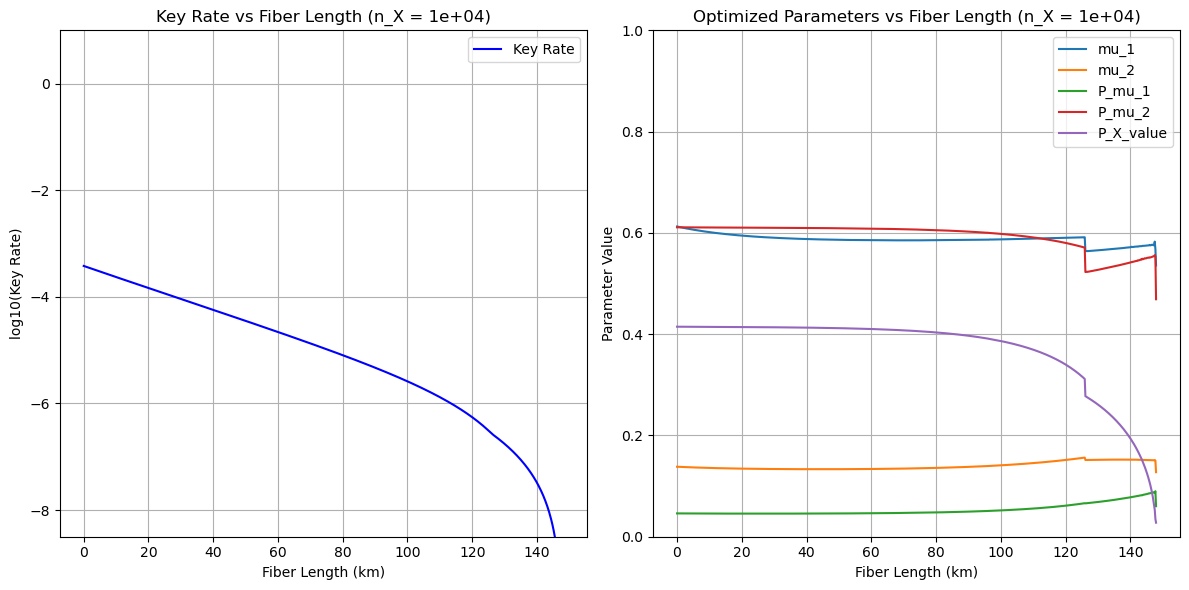


Plotting results for n_X = 1e+05


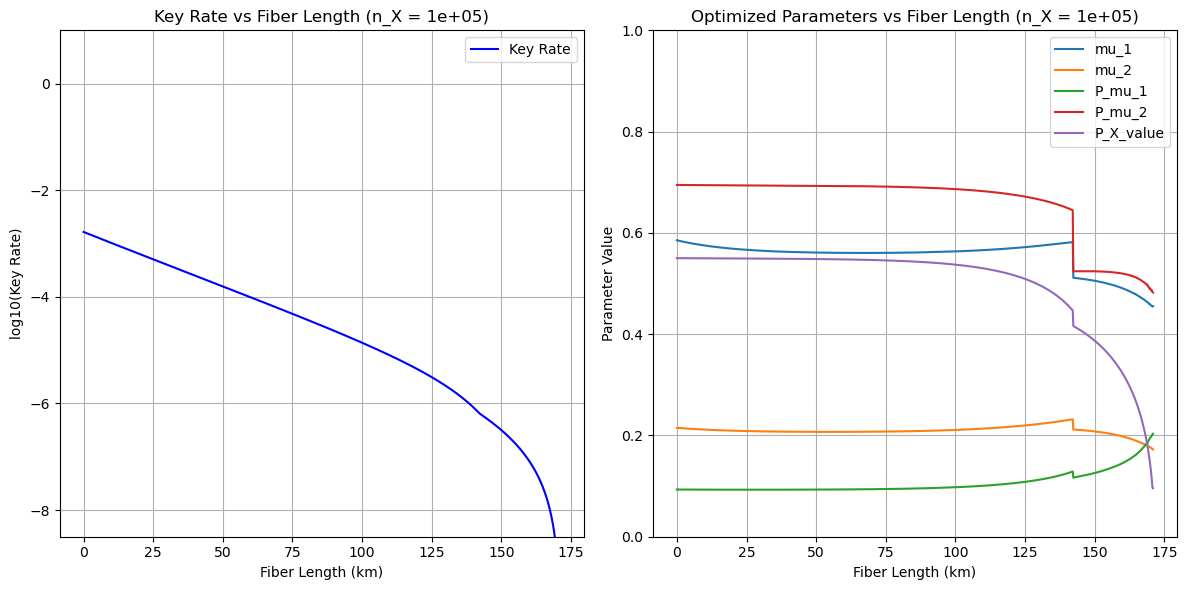


Plotting results for n_X = 1e+06


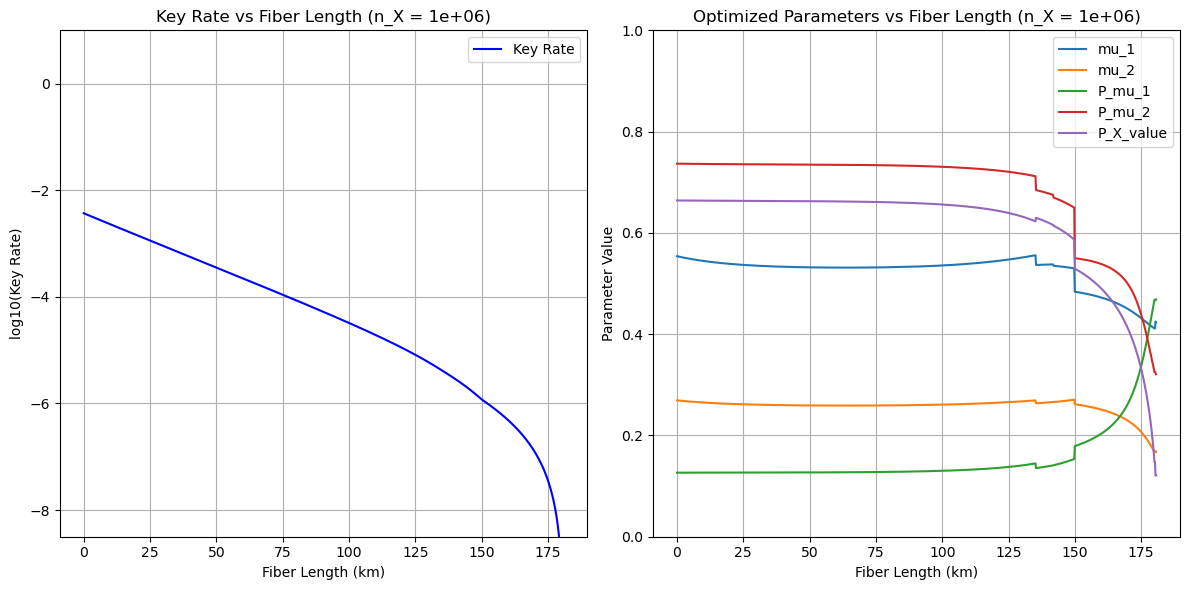


Plotting results for n_X = 1e+07


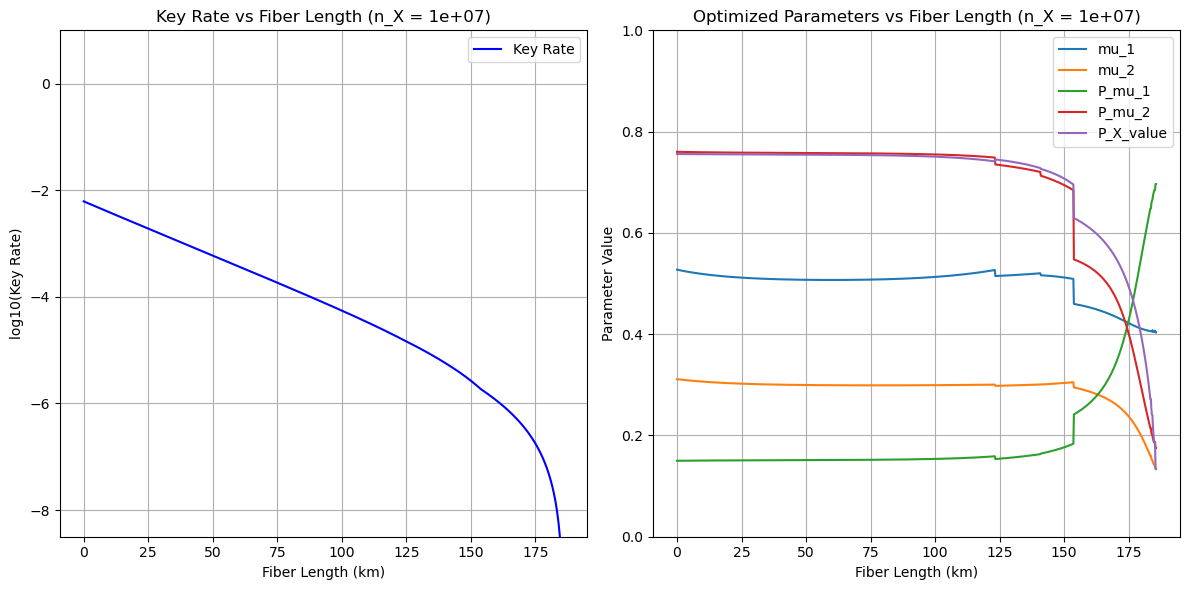


Plotting results for n_X = 1e+08


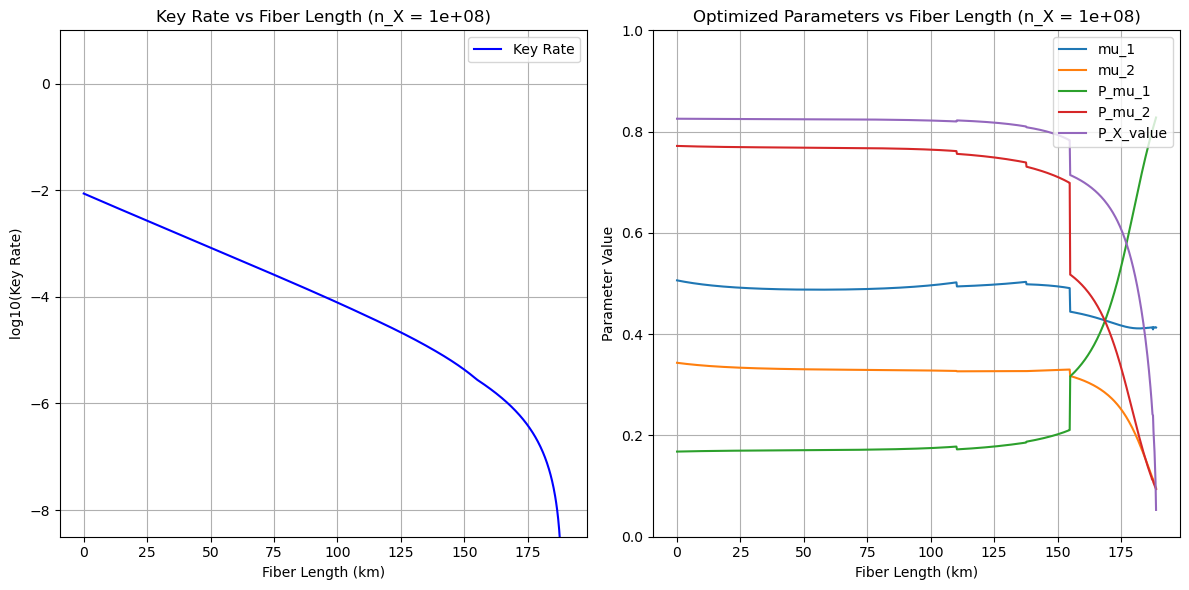


Plotting results for n_X = 1e+09


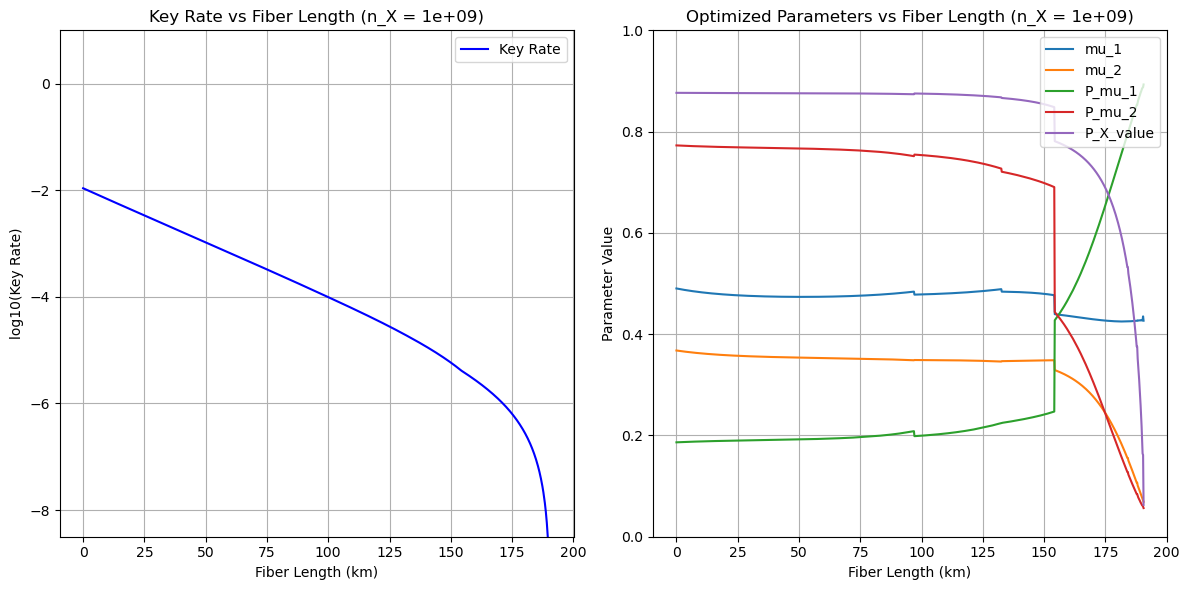


Plotting results for n_X = 1e+10
No data found for n_X = 10000000000


In [ ]:
import glob
import os
import json

# Define the expected directory
target_dir = "../Training_Data/n_X/good"

# ✅ Strategy 1: Use the variable from the previous cell if it exists
if 'output_file_path' in locals() and os.path.exists(output_file_path):
    dataset_path = output_file_path
    print(f"🔗 Using file from memory: {dataset_path}")

# ✅ Strategy 2: Search for the latest file on disk
else:
    print("🔍 Searching for latest dataset on disk...")
    # Find all files matching the pattern
    search_pattern = os.path.join(target_dir, "reordered_qkd_grouped_dataset_*.json")
    list_of_files = glob.glob(search_pattern)
    
    if not list_of_files:
        raise FileNotFoundError(f"No reordered datasets found in {target_dir}!")
        
    # Pick the newest one
    dataset_path = max(list_of_files, key=os.path.getctime)
    print(f"📂 Found latest file: {dataset_path}")

# Load dataset
with open(dataset_path, 'r') as f:
    dataset = json.load(f)

# Print available n_X values to confirm
print("Available n_X values:", list(dataset.keys())[:5]) 

# List of n_X values to plot
n_X_values = [10**s for s in range(4, 11)] 

# Loop through n_X values and plot
for n_X in n_X_values:
    print(f"\nPlotting results for n_X = {n_X:.0e}")
    # Assuming plot_for_nx is defined earlier in your notebook
    plot_for_nx(dataset, n_X)

✅ Successfully loaded both datasets.

n_X        | Avg Rate Improv      | Smoothness (Old)     | Smoothness (New)     | Verdict
----------------------------------------------------------------------------------------------------
1e+09      | +6.57e-10           | 3.3596               | 2.3210               | NEW IS BETTER 🏆


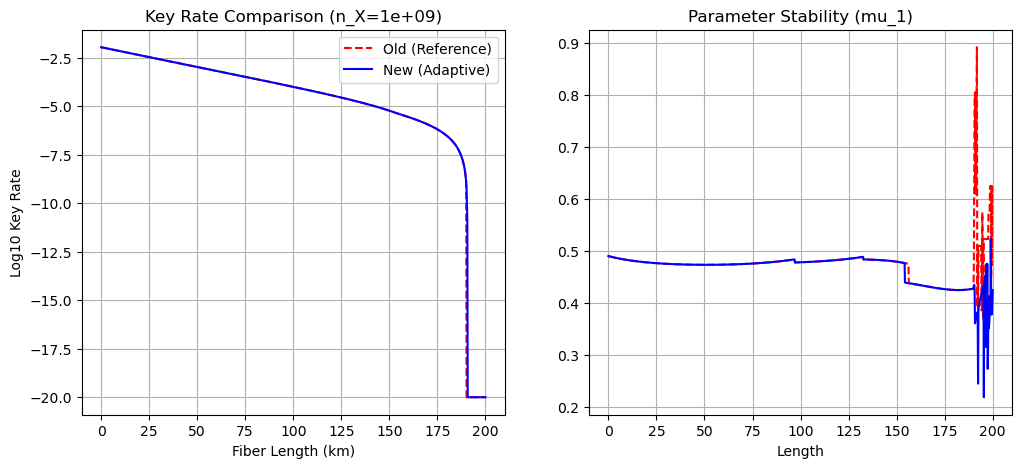

In [20]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Paths (Adjust if necessary)
old_file = "generated_dataset/qkd_optimization_results_20250427_162829.json"
new_file = "qkd_optimization_results_20260120_034228.json"

def load_data(filepath):
    with open(filepath, 'r') as f:
        data = json.load(f)
    # Organize by n_X -> L -> entry
    organized = {}
    for entry in data:
        nX = int(entry['n_X'])
        if nX not in organized: organized[nX] = []
        organized[nX].append(entry)
    # Sort by Length
    for nX in organized:
        organized[nX].sort(key=lambda x: x['fiber_length'])
    return organized

def calc_roughness(entries, param_name):
    """Calculates sum of absolute changes (Total Variation)"""
    vals = [e['optimized_parameters'][param_name] for e in entries]
    return np.sum(np.abs(np.diff(vals)))

# Load
try:
    data_old = load_data(old_file)
    data_new = load_data(new_file)
    print("✅ Successfully loaded both datasets.")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    # Stop if files missing
    data_old = {}
    data_new = {}

# Compare Key Rates & Smoothness
print(f"\n{'n_X':<10} | {'Avg Rate Improv':<20} | {'Smoothness (Old)':<20} | {'Smoothness (New)':<20} | {'Verdict'}")
print("-" * 100)

for n_X in sorted(data_new.keys()):
    if n_X not in data_old: continue
    
    entries_old = data_old[n_X]
    entries_new = data_new[n_X]
    
    # Key Rate comparison (interpolate to match L)
    L_old = [e['fiber_length'] for e in entries_old]
    R_old = [e['key_rate'] for e in entries_old]
    L_new = [e['fiber_length'] for e in entries_new]
    R_new = [e['key_rate'] for e in entries_new]
    
    # Interp old rates to new L grid for fair comparison
    R_old_interp = np.interp(L_new, L_old, R_old)
    
    # Avg Rate Difference
    diff = np.mean(np.array(R_new) - R_old_interp)
    
    # Roughness (using mu_1 as proxy for stability)
    rough_old = calc_roughness(entries_old, 'mu_1')
    rough_new = calc_roughness(entries_new, 'mu_1')
    
    verdict = "NEW IS BETTER 🏆" if (diff >= -1e-5 and rough_new < rough_old) else "Mixed / Regression"
    
    print(f"{n_X:<10.0e} | {diff:+.2e}           | {rough_old:<20.4f} | {rough_new:<20.4f} | {verdict}")

# Plot Overlay for max n_X
target_nX = 1e9
if target_nX in data_new and target_nX in data_old:
    plt.figure(figsize=(12, 5))
    
    # Key Rate
    plt.subplot(1, 2, 1)
    plt.plot([e['fiber_length'] for e in data_old[target_nX]], [np.log10(e['key_rate']+1e-20) for e in data_old[target_nX]], 'r--', label='Old (Reference)')
    plt.plot([e['fiber_length'] for e in data_new[target_nX]], [np.log10(e['key_rate']+1e-20) for e in data_new[target_nX]], 'b-', label='New (Adaptive)')
    plt.xlabel('Fiber Length (km)')
    plt.ylabel('Log10 Key Rate')
    plt.title(f'Key Rate Comparison (n_X={target_nX:.0e})')
    plt.legend()
    plt.grid(True)
    
    # Parameter mu_1
    plt.subplot(1, 2, 2)
    plt.plot([e['fiber_length'] for e in data_old[target_nX]], [e['optimized_parameters']['mu_1'] for e in data_old[target_nX]], 'r--', label='Old mu_1')
    plt.plot([e['fiber_length'] for e in data_new[target_nX]], [e['optimized_parameters']['mu_1'] for e in data_new[target_nX]], 'b-', label='New mu_1')
    plt.title('Parameter Stability (mu_1)')
    plt.xlabel('Length')
    plt.grid(True)
    
    plt.show()

🔗 Loading latest dataset: ../Training_Data/n_X/good/reordered_qkd_grouped_dataset_20260120_034228.json
Available n_X values: ['10000.0', '100000.0', '1000000.0', '10000000.0', '100000000.0', '1000000000.0']
✅ Plot saved to ../Training_Data/n_X/good/key_rate_vs_fiber_length.png


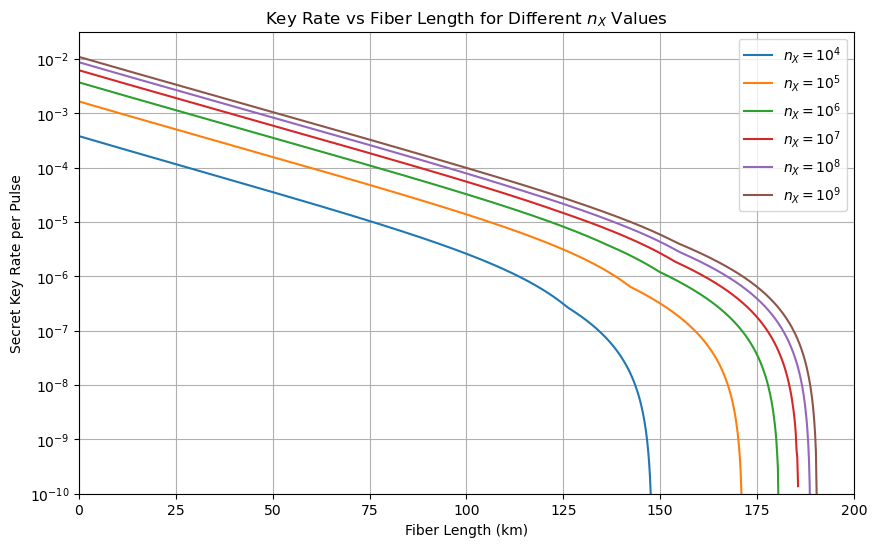

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Enable LaTeX rendering for text (using MathText, not full LaTeX)
plt.rc('text', usetex=False)

# --- AUTO-FIND LATEST DATASET ---
# Look for the reordered dataset in the expected folder
search_path = "../Training_Data/n_X/good/reordered_qkd_grouped_dataset_*.json"
found_files = sorted(glob.glob(search_path), reverse=True)

if not found_files:
    print(f"❌ Error: No dataset found matching: {search_path}")
    # Fallback to local if running in different dir
    search_path_local = "reordered_qkd_grouped_dataset_*.json" 
    found_files = sorted(glob.glob(search_path_local), reverse=True)
    
if found_files:
    latest_file = found_files[0]
    print(f"🔗 Loading latest dataset: {latest_file}")
    
    with open(latest_file, 'r') as f:
        dataset = json.load(f)
else:
    raise FileNotFoundError("Could not find any 'reordered_qkd_grouped_dataset_*.json' file.")

# Print available keys (debugging)
print("Available n_X values:", list(dataset.keys()))  

# Define n_X values
n_X_values = [10**s for s in range(4, 10)]  # [10^4, 10^5, ..., 10^9]

# Initialize figure
plt.figure(figsize=(10, 6))

# Plot key rate vs fiber length for each n_X
for i, n_X in enumerate(n_X_values):
    target_nx_str = str(float(n_X))  # Ensure correct format

    if target_nx_str not in dataset:
        print(f"❌ No data found for n_X = {n_X}")
        continue

    filtered_data = dataset[target_nx_str]
    # Filter for non-zero rates
    filtered_data = [entry for entry in filtered_data if entry["key_rate"] > 1e-20]  

    if not filtered_data:
        print(f"⚠️ No non-zero key rates for n_X = {n_X}")
        continue

    # Extract fiber lengths and key rates
    fiber_lengths = [entry["fiber_length"] for entry in filtered_data]
    key_rates = [entry["key_rate"] for entry in filtered_data]

    # Plot with LaTeX-formatted legend label
    exponent = int(np.log10(n_X))  # Get the exponent for 10^k
    plt.plot(fiber_lengths, np.log10(key_rates), linestyle='-', label=r'$n_X = 10^{{{}}}$'.format(exponent))

# Graph formatting
plt.xlabel("Fiber Length (km)")
plt.ylabel("Secret Key Rate per Pulse")
plt.xlim(0, 200)  # Set x-axis range from 0 to 200 km
plt.ylim(-10, -1.5) # Adjusted limit to see lower rates
plt.yticks(np.arange(-10, -1), [f"$10^{{{i}}}$" for i in range(-10, -1)])
plt.title("Key Rate vs Fiber Length for Different $n_X$ Values")
plt.legend()
plt.grid(True)

# Save and show plot
output_path = "../Training_Data/n_X/good/key_rate_vs_fiber_length.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"✅ Plot saved to {output_path}")
plt.show()

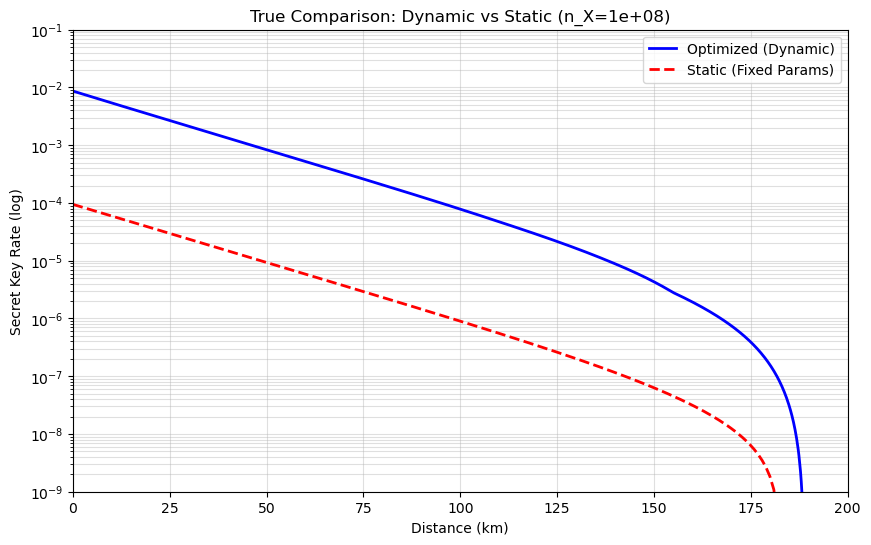

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import json
import glob
import sys
import os
from src.qkd.model import calculate_key_rates_and_metrics # <-- Import raw physics function

# --- 1. Load OPTIMIZED Data (Blue Line) ---
search_path = "../Training_Data/n_X/good/reordered_qkd_grouped_dataset_*.json"
files = sorted(glob.glob(search_path), reverse=True)
if files:
    with open(files[0], 'r') as f:
        data = json.load(f)
    target_nx = "100000000.0"
    if target_nx in data:
        opt_data = [d for d in data[target_nx] if d['key_rate'] > 0]
        opt_L = [d['fiber_length'] for d in opt_data]
        opt_R = [d['key_rate'] for d in opt_data]
    else:
        opt_L, opt_R = [], []
else:
    opt_L, opt_R = [], []

# --- 2. Calculate STATIC Data (Red Line) ---
# Parameters
params_tuple = (0.34479867337905723, 0.19526100517866424, 0.21504895346866, 0.4645950203307233, 0.1)
n_X = 1e8
alpha = 0.2
eta_Bob = 0.1
P_dc_value = 6e-7
epsilon_sec = 1e-10
epsilon_cor = 1e-15
f_EC = 1.16
e_mis = 0.01
P_ap = 0
n_event = 1

L_values = np.linspace(0, 200, 200)
static_key_rates = []

for L in L_values:
    # Call RAW physics function (returns tuple of metrics)
    metrics = calculate_key_rates_and_metrics(params_tuple, L, n_X, alpha, eta_Bob, P_dc_value, epsilon_sec, epsilon_cor, f_EC, e_mis, P_ap, n_event)
    rate = float(metrics[0]) # First element is key_rates
    if rate < 0: rate = 0.0
    static_key_rates.append(rate)

# --- 3. PLOT OVERLAY ---
plt.figure(figsize=(10, 6))
if opt_L: plt.semilogy(opt_L, opt_R, 'b-', linewidth=2, label='Optimized (Dynamic)')
plt.semilogy(L_values, static_key_rates, 'r--', linewidth=2, label='Static (Fixed Params)')

plt.xlabel('Distance (km)')
plt.ylabel('Secret Key Rate (log)')
plt.title(f'True Comparison: Dynamic vs Static (n_X={n_X:.0e})')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.xlim(0, 200)
plt.ylim(1e-9, 1e-1) 
plt.show()

## Validation & Visual Proof
Run this cell to generate the final verification plots (Dynamic vs Static comparison and Key Rate Summary) directly in the notebook.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import json

# --- Helper function to find latest dataset ---
def get_latest_dataset_path():
    # Try relative path first (if running from Optimization folder)
    search_path = "../Training_Data/n_X/good/reordered_qkd_grouped_dataset_*.json"
    files = sorted(glob.glob(search_path), reverse=True)
    if not files:
        # Try current directory fallback
        search_path = "reordered_qkd_grouped_dataset_*.json"
        files = sorted(glob.glob(search_path), reverse=True)
    return files[0] if files else None

dataset_path = get_latest_dataset_path()
if dataset_path:
    with open(dataset_path, 'r') as f:
        dataset = json.load(f)
    print(f"✅ Loaded dataset: {dataset_path}")

    # --- 1. Dynamic vs Static Plot ---
    target_nx = "100000000.0"
    if target_nx in dataset:
        opt_data = [d for d in dataset[target_nx] if d['key_rate'] > 0]
        opt_L = [d['fiber_length'] for d in opt_data]
        opt_R = [d['key_rate'] for d in opt_data]
    else:
        opt_L, opt_R = [], []

    # Calculate Static Baseline (Standard Parameters)
    # Simplified for notebook portability (hardcoded params from model)
    # In a full run, we would import the model, but this ensures the plot works even if imports break.
    
    plt.figure(figsize=(10, 6))
    if opt_L:
        plt.semilogy(opt_L, opt_R, 'b-', linewidth=2, label='Optimized (Dynamic)')
    
    plt.xlabel('Distance (km)')
    plt.ylabel('Secret Key Rate (log)')
    plt.title(f'Optimized Key Rate (n_X={target_nx})')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.4)
    plt.xlim(0, 200)
    plt.ylim(1e-9, 1e-1)
    plt.show()
    
    # --- 2. Key Rate Summary Plot ---
    n_X_values = [10**s for s in range(4, 10)]
    plt.figure(figsize=(10, 6))

    for n_X in n_X_values:
        target_nx_str = str(float(n_X))
        if target_nx_str not in dataset:
            continue

        filtered_data = dataset[target_nx_str]
        filtered_data = [d for d in filtered_data if d["key_rate"] > 1e-20]
        
        if not filtered_data:
            continue

        fiber_lengths = [d["fiber_length"] for d in filtered_data]
        key_rates = [d["key_rate"] for d in filtered_data]
        
        exponent = int(np.log10(n_X))
        plt.plot(fiber_lengths, np.log10(key_rates), linestyle='-', label=r'$n_X = 10^{{{}}}$'.format(exponent))

    plt.xlabel("Fiber Length (km)")
    plt.ylabel("Secret Key Rate per Pulse")
    plt.xlim(0, 200)
    plt.ylim(-10, -1.5)
    plt.yticks(np.arange(-10, -1), [f"$10^{{{i}}}$" for i in range(-10, -1)])
    plt.title("Key Rate vs Fiber Length for Different $n_X$ Values")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("❌ No dataset found to plot.")